# 0: Introduction

Inspiration for report can be taken from the following example:
https://documents1.worldbank.org/curated/en/798061467991025474/pdf/97883-PUB-9781464805394-PUBLIC-Box391491B-P143636.pdf

More information about the data:
https://microdata.worldbank.org/catalog/4156/data-dictionary/F4?file_name=fs.sav

In [25]:
import sys
print(sys.executable)

/home/vm/miniconda3/bin/python


# 1: Loading data and defining features

In [26]:
import pyreadstat

fs, meta = pyreadstat.read_sav("Ghana MICS6 SPSS Datasets/fs.sav")
hh, meta_hh = pyreadstat.read_sav("Ghana MICS6 SPSS Datasets/hh.sav")
meta.missing_ranges
labels = meta.column_names_to_labels

merged = fs.merge(
    hh[["HH1", "HH2", "HHSEX", "HHAGE", "helevel"]],
    on=["HH1", "HH2"],
    how="left"
)

categorical_cols = ["HL4", "HHSEX", "ED5A", "helevel"]

for col in categorical_cols:
    if col in merged.columns:
        merged[col] = merged[col].astype("category").cat.codes

In [ ]:
features = [
    # Child labour

    "CL3",    # hours worked in the past week
    "CL5",    # hazardous work: Activities required working with dangerous tools or heavy machinery  
    "CL6A",   # hazardous work: exposed to dust, fumes, or gas 
    "CL6B",   # hazardous work: exposed to extreme temperatures or humidity
    "CL6C",   # hazardous work: exposed to loud noise or vibration 
    "CL6D",   # hazardous work: required to work at heights 
    "CL6E",   # hazardous work: required to work with chemicals 
    "CL6X",   # hazardous work: exposed to other 

    # Engaged in other activity for income in the past week
    #"CL1A",   # worked or helped on garden in past week
    # Engaged in other activity in the past week

    # Child demographics
    "CB3",  # age. Don't know if FSAGE or CB3 is correct
    "HL4",    # sex (if exists)

    # Education
    "ED5A", # Highest level of education attended
    "ED5B", # Highest grade attended at ED5A
    "fselevel", # Child's education
    #"PR5", # Child ever had homework

    # Socio-economic
    #"windex5",
    "wscore", # Combined wealth score

    # Household head
    "HHSEX",   # sex of head
    "HHAGE",   # age of head
    "helevel"  # education of head
]

df = merged[[f for f in features if f in merged.columns]].copy()


df = df.replace('', float('nan'))

num_cols = df.select_dtypes(include="number").columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

hazard_cols = ["CL6A", "CL6B", "CL6C", "CL6D", "CL6E", "CL6X"]

existing_hazard_cols = [col for col in hazard_cols if col in df.columns]

df["hazard_index"] = df[existing_hazard_cols].sum(axis=1)

df = df.drop(columns=existing_hazard_cols)

categorical_cols = ["HL4", "HHSEX", "ED5A", "helevel"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category").cat.codes


labels = meta.column_names_to_labels

feature_labels = {
    f: labels.get(f, "No description available")
    for f in df.columns
}


# 2: Creating the model

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

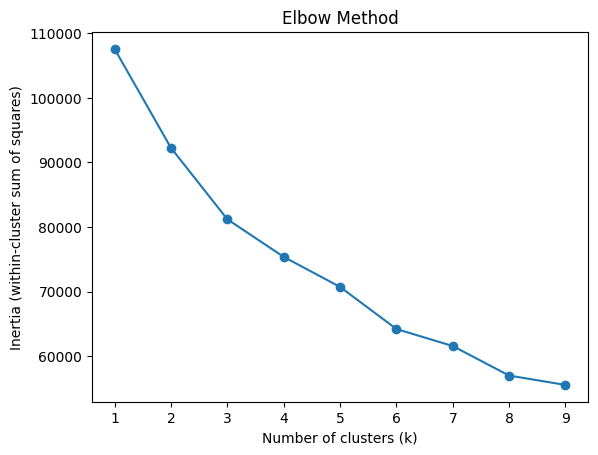

In [29]:
inertia = []

K_range = range(1, 10)

for k_test in K_range:
    kmeans = KMeans(n_clusters=k_test, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.title("Elbow Method")
plt.show()


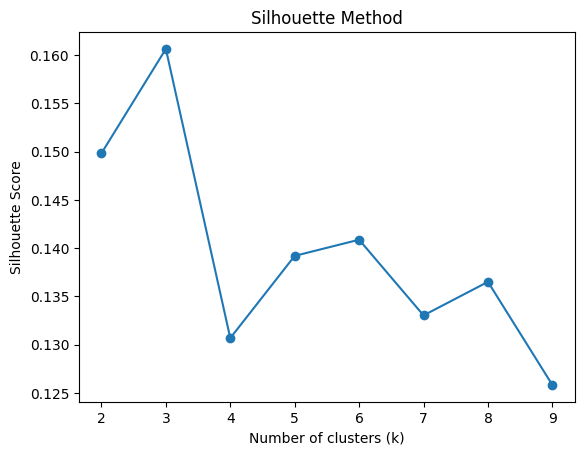

In [30]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

K_range = range(2, 10)

for k_test in K_range:
    kmeans = KMeans(n_clusters=k_test, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()


In [ ]:
# Should be adjusted based on findings above
k = 3

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_summary = df.groupby("cluster").mean()
print(cluster_summary)

               CL3       CL5        CB3       HL4      ED5A      ED5B  \
cluster                                                                 
0         5.307258  2.000736   9.845022  0.483570  0.772683  3.237862   
1        13.661244  1.200000  13.046890  0.385646  1.355981  3.219139   
2         5.112441  1.996356  10.542686  0.525508  3.950026  3.305310   

         fselevel    wscore     HHSEX      HHAGE   helevel  hazard_index  
cluster                                                                   
0        0.882295 -0.634413  0.346984  51.415400  0.544139     11.900196  
1        1.266986 -0.652177  0.297608  51.750239  0.873684     10.464115  
2        1.237637  0.634557  0.326132  45.534617  2.450547     11.940916  


# 3: Analysing and visualizing

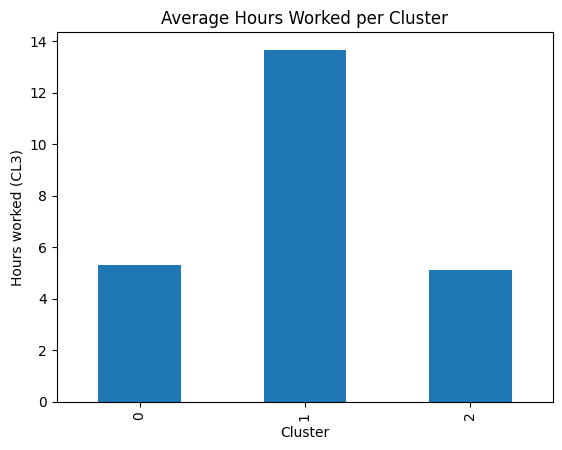

In [ ]:
df.groupby("cluster")["CL3"].mean().plot(kind="bar")
plt.title("Average Hours Worked per Cluster")
plt.ylabel("Hours worked (CL3)")
plt.xlabel("Cluster")
plt.show()

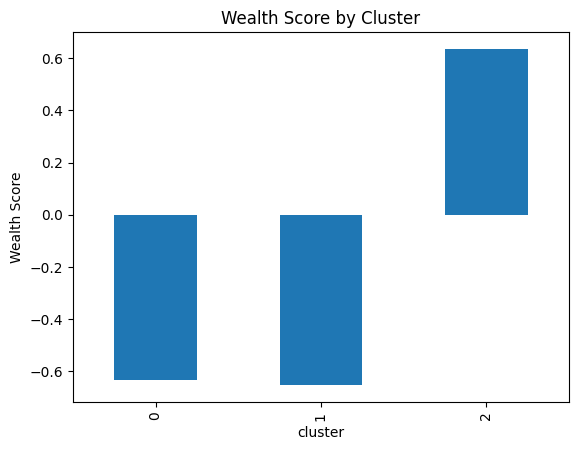

In [ ]:
df.groupby("cluster")["wscore"].mean().plot(kind="bar")
plt.title("Wealth Score by Cluster")
plt.ylabel("Wealth Score")
plt.show()

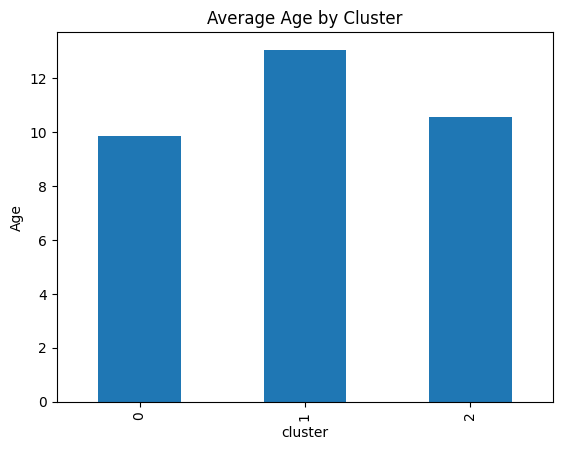

In [34]:
df.groupby("cluster")["CB3"].mean().plot(kind="bar")
plt.title("Average Age by Cluster")
plt.ylabel("Age")
plt.show()


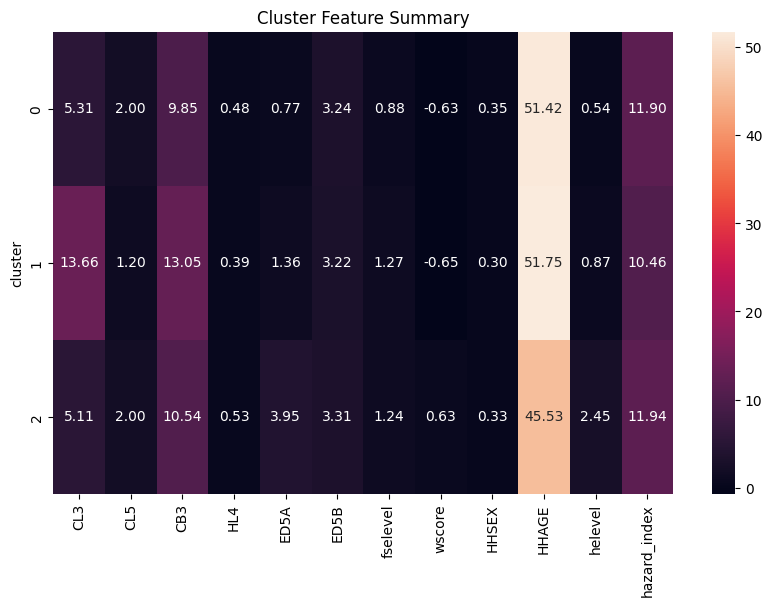

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.groupby("cluster").mean(), annot=True, fmt=".2f")
plt.title("Cluster Feature Summary")
plt.show()

          CL3       CL5       CB3       HL4      ED5A      ED5B  fselevel  \
PC1 -0.207094  0.269737 -0.104236  0.065343  0.505392  0.046316  0.064149   
PC2  0.200370 -0.282652  0.596323  0.003226  0.132429  0.062843  0.587434   

       wscore     HHSEX     HHAGE   helevel  hazard_index  
PC1  0.483464 -0.003728 -0.185925  0.510993      0.279472  
PC2  0.192273  0.025076  0.150304  0.160696     -0.267900  
[0.2098393  0.16596773]


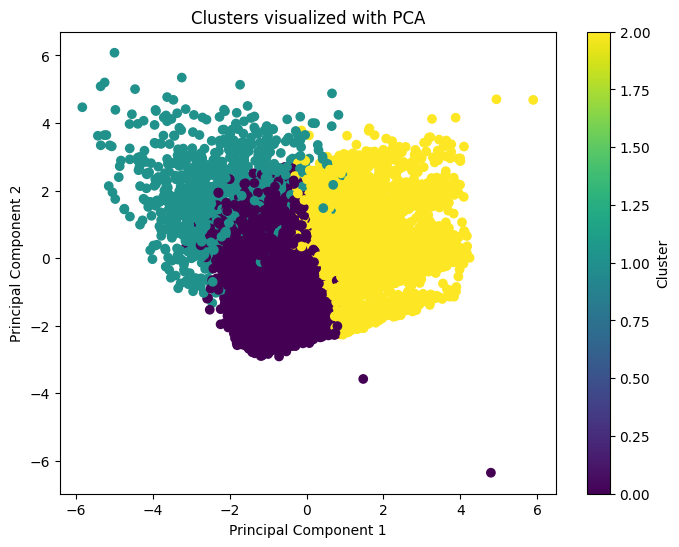

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import pandas as pd

pca_components = pd.DataFrame(
    pca.components_,
    columns=df.drop(columns="cluster").columns,
    index=["PC1", "PC2"]
)

print(pca_components)
print(pca.explained_variance_ratio_)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df["cluster"])
plt.title("Clusters visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter, label="Cluster")
plt.show()


# 4: Defining the profiles

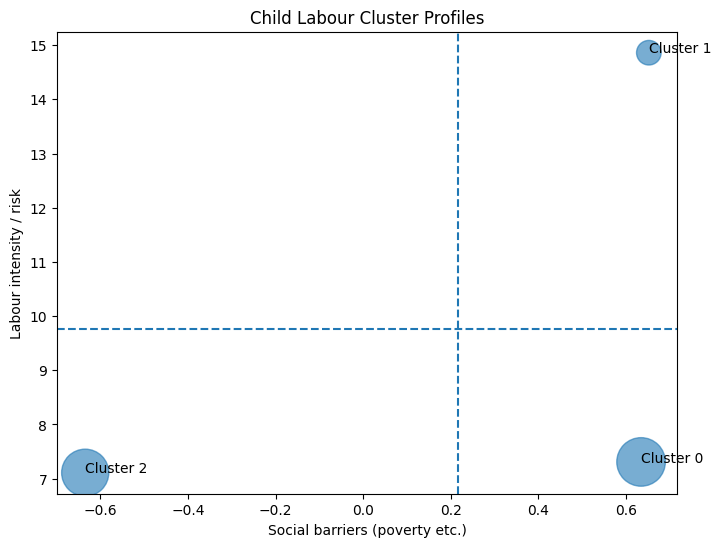

In [46]:
social_barrier = (
    - df["wscore"]   # poorer = higher barrier
)

labour_barrier = (
    df["CL3"] + df["CL5"]
)

plot_df = df.copy()
plot_df["social_barrier"] = -plot_df["wscore"]
plot_df["labour_barrier"] = plot_df["CL3"] + plot_df["CL5"]

cluster_plot = plot_df.groupby("cluster").agg({
    "social_barrier": "mean",
    "labour_barrier": "mean",
    "cluster": "count"
}).rename(columns={"cluster": "size"}).reset_index()

plt.figure(figsize=(8,6))

plt.scatter(
    cluster_plot["social_barrier"],
    cluster_plot["labour_barrier"],
    s=cluster_plot["size"] * 0.3,  # bubble size
    alpha=0.6
)

for i, row in cluster_plot.iterrows():
    plt.text(row["social_barrier"], row["labour_barrier"], f"Cluster {int(row['cluster'])}")

plt.xlabel("Social barriers (poverty etc.)")
plt.ylabel("Labour intensity / risk")
plt.title("Child Labour Cluster Profiles")

plt.axhline(cluster_plot["labour_barrier"].mean(), linestyle="--")
plt.axvline(cluster_plot["social_barrier"].mean(), linestyle="--")


plt.show()

plot_df[["social_barrier", "labour_barrier"]] = scaler.fit_transform(
    plot_df[["social_barrier", "labour_barrier"]]
)


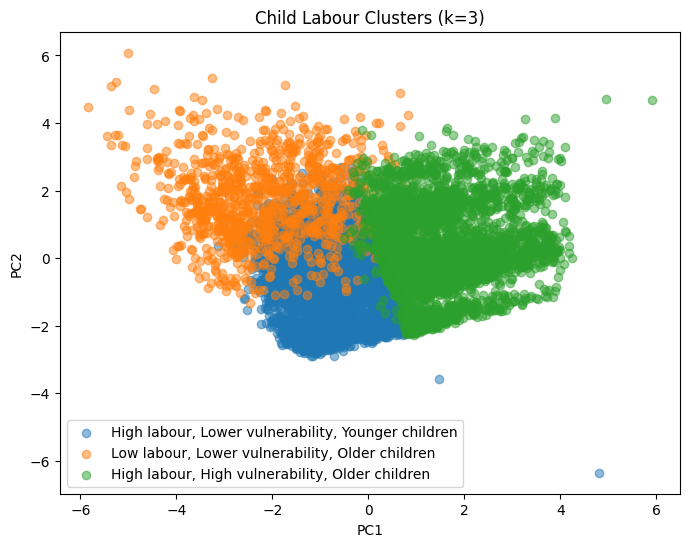

In [43]:
cluster_summary = df.groupby("cluster").mean(numeric_only=True)

cluster_names = {}

for cluster_id, row in cluster_summary.iterrows():
    
    label = ""
    
    # Labour
    if row["labour_barrier"] > df["labour_barrier"].mean():
        label += "High labour"
    else:
        label += "Low labour"
    
    # Social
    if row["social_barrier"] > df["social_barrier"].mean():
        label += ", High vulnerability"
    else:
        label += ", Lower vulnerability"
    
    # Age (nice extra context)
    if row["CB3"] > df["CB3"].mean():
        label += ", Older children"
    else:
        label += ", Younger children"
    
    cluster_names[cluster_id] = label

df["cluster_label"] = df["cluster"].map(cluster_names)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    
    plt.scatter(
        X_pca[subset.index, 0],
        X_pca[subset.index, 1],
        label=subset["cluster_label"].iloc[0],
        alpha=0.5
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"Child Labour Clusters (k={k})")

plt.legend()
plt.show()